# Continuous Authentication using UEBA and Hybrid Modeling

## Importing Libraries and Dataset

In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
WORKING_DIR = '/content/drive/MyDrive/Continuous Auth using UEBA'
DATASET_PATH = '/dataset/processed/lanl-auth-dataset-1-00.csv'

In [10]:
df = pd.read_csv(f'{WORKING_DIR}/{DATASET_PATH}')

In [11]:
df = df[:100000]

In [12]:
df.head()

,timestamp,user,computer,datetime,hour_of_day,day_of_week,login_frequency,inter_event_time,avg_inter_event_time,time_since_last_login,unique_hosts,host_entropy,top_host_ratio,degree_centrality
0,1,U1,C1,2014-01-01 00:00:01,0,2,1.0,0.0,23.566820,0.0,12,2.978570,0.211982,0.001451
1,1,U1,C2,2014-01-01 00:00:01,0,2,3600.0,0.0,23.566820,0.0,12,2.978570,0.211982,0.001451
2,2,U2,C3,2014-01-01 00:00:02,0,2,1.0,0.0,75.338235,0.0,2,0.908178,0.676471,0.000242
3,3,U3,C4,2014-01-01 00:00:03,0,2,1.0,0.0,61.458824,0.0,4,1.197341,0.694118,0.000484
4,6,U4,C5,2014-01-01 00:00:06,0,2,1.0,0.0,14.652893,0.0,2,0.829313,0.738292,0.000242


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   timestamp              100000 non-null  int64  
 1   user                   100000 non-null  object 
 2   computer               100000 non-null  object 
 3   datetime               100000 non-null  object 
 4   hour_of_day            100000 non-null  int64  
 5   day_of_week            100000 non-null  int64  
 6   login_frequency        100000 non-null  float64
 7   inter_event_time       100000 non-null  float64
 8   avg_inter_event_time   100000 non-null  float64
 9   time_since_last_login  100000 non-null  float64
 10  unique_hosts           100000 non-null  int64  
 11  host_entropy           100000 non-null  float64
 12  top_host_ratio         100000 non-null  float64
 13  degree_centrality      100000 non-null  float64
dtypes: float64(7), int64(4), object(3)
me

## Feature Engineering

In [ ]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s', origin='2014-01-01')
df['hour_of_day'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek

In [ ]:
df['login_frequency'] = (
    df.groupby('user')['datetime'].transform(lambda x: x.diff().dt.total_seconds().rsub(3600).clip(lower=0))
)
df['login_frequency'] = df['login_frequency'].fillna(1)

In [ ]:
df['inter_event_time'] = df.groupby('user')['datetime'].diff().dt.total_seconds()
df['inter_event_time'] = df['inter_event_time'].fillna(0)
df['avg_inter_event_time'] = df.groupby('user')['inter_event_time'].transform('mean')
df['avg_inter_event_time'] = df['avg_inter_event_time'].fillna(0)

In [ ]:
df['time_since_last_login'] = df.groupby('user')['datetime'].diff().dt.total_seconds().fillna(0)

In [ ]:
user_hosts = df.groupby('user')['computer'].nunique()
df = df.merge(user_hosts.rename('unique_hosts'), on='user')

In [ ]:
def entropy(x):
  p = x.value_counts(normalize=True)
  return -(p * np.log2(p)).sum()

In [ ]:
entropy_map = df.groupby('user')['computer'].apply(entropy)
df = df.merge(entropy_map.rename('host_entropy'), on='user')

In [ ]:
def top_ratio(x):
    counts = x.value_counts(normalize=True)
    return counts.iloc[0] if len(counts) > 0 else 0

In [ ]:
ratio_map = df.groupby('user')['computer'].apply(top_ratio)
df = df.merge(ratio_map.rename('top_host_ratio'), on='user')

In [ ]:
B = nx.Graph()
B.add_edges_from(df[['user', 'computer']].itertuples(index=False, name=None))

centrality = nx.degree_centrality(B)
user_centrality = {u: centrality[u] for u in df['user'].unique() if u in centrality}

df['degree_centrality'] = df['user'].map(user_centrality)

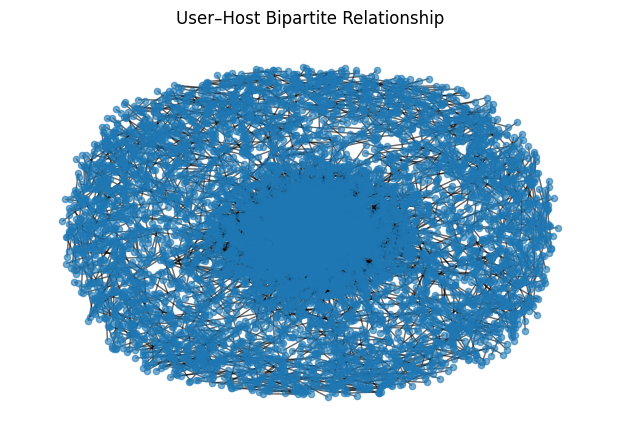

In [ ]:
plt.figure(figsize=(6,4))
nx.draw(B, node_size=20, alpha=0.6)
plt.title('User–Host Bipartite Relationship')
plt.show()

In [ ]:
df.head()

,timestamp,user,computer,datetime,hour_of_day,day_of_week,login_frequency,inter_event_time,avg_inter_event_time,time_since_last_login,unique_hosts,host_entropy,top_host_ratio,degree_centrality
0,1,U1,C1,2014-01-01 00:00:01,0,2,1.0,0.0,23.566820,0.0,12,2.978570,0.211982,0.001451
1,1,U1,C2,2014-01-01 00:00:01,0,2,3600.0,0.0,23.566820,0.0,12,2.978570,0.211982,0.001451
2,2,U2,C3,2014-01-01 00:00:02,0,2,1.0,0.0,75.338235,0.0,2,0.908178,0.676471,0.000242
3,3,U3,C4,2014-01-01 00:00:03,0,2,1.0,0.0,61.458824,0.0,4,1.197341,0.694118,0.000484
4,6,U4,C5,2014-01-01 00:00:06,0,2,1.0,0.0,14.652893,0.0,2,0.829313,0.738292,0.000242


In [ ]:
df.to_csv('/content/drive/MyDrive/LANL Authentication Dataset/processed/lanl-auth-dataset-1-00.csv', index=False)

## Preparation for Training

In [8]:
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [14]:
autoencoder_features = ['unique_hosts', 'host_entropy', 'top_host_ratio', 'degree_centrality', 'hour_of_day', 'day_of_week']
isoforest_features = ['login_frequency', 'avg_inter_event_time', 'time_since_last_login']

X_global = df[autoencoder_features].fillna(0)
X_user = df[isoforest_features].fillna(0)

In [15]:
X_global_train, X_global_val = train_test_split(X_global, test_size=0.2, random_state=32)
X_user_train, X_user_val = train_test_split(X_user, test_size=0.2, random_state=32)

In [17]:
with open(f'{WORKING_DIR}/scalers/global_scaler.pkl', 'rb') as gsf:
  global_scaler = pickle.load(gsf)

In [18]:
with open(f'{WORKING_DIR}/scalers/user_scaler.pkl', 'rb') as usf:
  user_scaler = pickle.load(usf)

In [19]:
X_global_train_scaled = global_scaler.transform(X_global_train)
X_global_val_scaled = global_scaler.transform(X_global_val)

In [20]:
X_user_train_scaled = user_scaler.transform(X_user_train)
X_user_val_scaled = user_scaler.transform(X_user_val)

In [21]:
class GlobalDataset(Dataset):
  def __init__(self, global_data) -> None:
    self.X = torch.tensor(global_data, dtype=torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx]

In [53]:
len(X_global_val_scaled) == len(X_user_val_scaled)

True

## Training and Evaluation

In [22]:
from tqdm import tqdm
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

### AutoEncoder

In [30]:
class AutoEncoder(nn.Module):
  def __init__(self, input_dim) -> None:
    super(AutoEncoder, self).__init__()

    dim_1 = input_dim // 2
    dim_2 = input_dim // 4

    self.encoder = nn.Sequential(
        nn.Linear(input_dim, dim_1),
        nn.ReLU(),
        nn.Linear(dim_1, dim_2),
    )
    self.decoder = nn.Sequential(
        nn.Linear(dim_2, dim_1),
        nn.ReLU(),
        nn.Linear(dim_1, input_dim),
    )

  def forward(self, X):
    return self.decoder(self.encoder(X))

In [31]:
def train_autoencoder(features, scaled_train_data, scaled_val_data):
    input_dim = len(features)
    epochs = 25
    lr = 1e-3
    batch_size = 128
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    train_dataloader = DataLoader(GlobalDataset(scaled_train_data), batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(GlobalDataset(scaled_val_data), batch_size=batch_size, shuffle=False)

    model = AutoEncoder(input_dim).to(device)
    criterion = nn.MSELoss(reduction='none')  # <-- per-sample loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss_history = []
    val_loss_history = []
    train_recon_errors = []
    val_recon_errors = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        for batch in train_dataloader:
            batch = batch.to(device)
            recon = model(batch)

            # Mean squared error per sample
            loss_per_sample = criterion(recon, batch).mean(dim=1)
            loss = loss_per_sample.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * batch.size(0)
            train_recon_errors.extend(loss_per_sample.detach().cpu().numpy())

        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for batch in val_dataloader:
                batch = batch.to(device)
                recon = model(batch)
                loss_per_sample = criterion(recon, batch).mean(dim=1)
                loss = loss_per_sample.mean()

                epoch_val_loss += loss.item() * batch.size(0)
                val_recon_errors.extend(loss_per_sample.cpu().numpy())

        epoch_train_loss /= len(train_dataloader.dataset)
        epoch_val_loss /= len(val_dataloader.dataset)

        train_loss_history.append(epoch_train_loss)
        val_loss_history.append(epoch_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.6f} | "
              f"Val Loss: {epoch_val_loss:.6f}")

    return model, train_recon_errors, val_recon_errors, train_loss_history, val_loss_history

In [32]:
trained_model, train_recon_errors, val_recon_errors, train_loss_history, val_loss_history = train_autoencoder(
    autoencoder_features,
    X_global_train_scaled,
    X_global_val_scaled
)

Epoch 1/25 | Train Loss: 0.453155 | Val Loss: 0.276328
Epoch 2/25 | Train Loss: 0.245595 | Val Loss: 0.214168
Epoch 3/25 | Train Loss: 0.193358 | Val Loss: 0.177767
Epoch 4/25 | Train Loss: 0.173713 | Val Loss: 0.172822
Epoch 5/25 | Train Loss: 0.171391 | Val Loss: 0.171249
Epoch 6/25 | Train Loss: 0.169779 | Val Loss: 0.168997
Epoch 7/25 | Train Loss: 0.166184 | Val Loss: 0.162537
Epoch 8/25 | Train Loss: 0.151874 | Val Loss: 0.130856
Epoch 9/25 | Train Loss: 0.100640 | Val Loss: 0.083512
Epoch 10/25 | Train Loss: 0.075665 | Val Loss: 0.074603
Epoch 11/25 | Train Loss: 0.071218 | Val Loss: 0.072383
Epoch 12/25 | Train Loss: 0.069646 | Val Loss: 0.070825
Epoch 13/25 | Train Loss: 0.068633 | Val Loss: 0.069898
Epoch 14/25 | Train Loss: 0.067862 | Val Loss: 0.069072
Epoch 15/25 | Train Loss: 0.067321 | Val Loss: 0.068359
Epoch 16/25 | Train Loss: 0.066900 | Val Loss: 0.067879
Epoch 17/25 | Train Loss: 0.066584 | Val Loss: 0.068214
Epoch 18/25 | Train Loss: 0.066346 | Val Loss: 0.067342
E

In [34]:
torch.save(trained_model.state_dict(), 'autoencoder.pth')

In [87]:
from cycler import cycler

plt.rcParams.update({
   "font.family": "serif",
   "font.serif": ["Times New Roman", "DejaVu Serif"],
   "mathtext.fontset": "stix",
   "axes.labelsize": 12,
   "axes.titlesize": 14,
   "legend.fontsize": 10,
   "xtick.labelsize": 10,
   "ytick.labelsize": 10,
   "axes.prop_cycle": cycler('color', ['#440154', '#31688e', '#35b779', '#fde725']),
   "image.cmap": "viridis",
   "patch.edgecolor": "black",
   "patch.force_edgecolor": True,
})

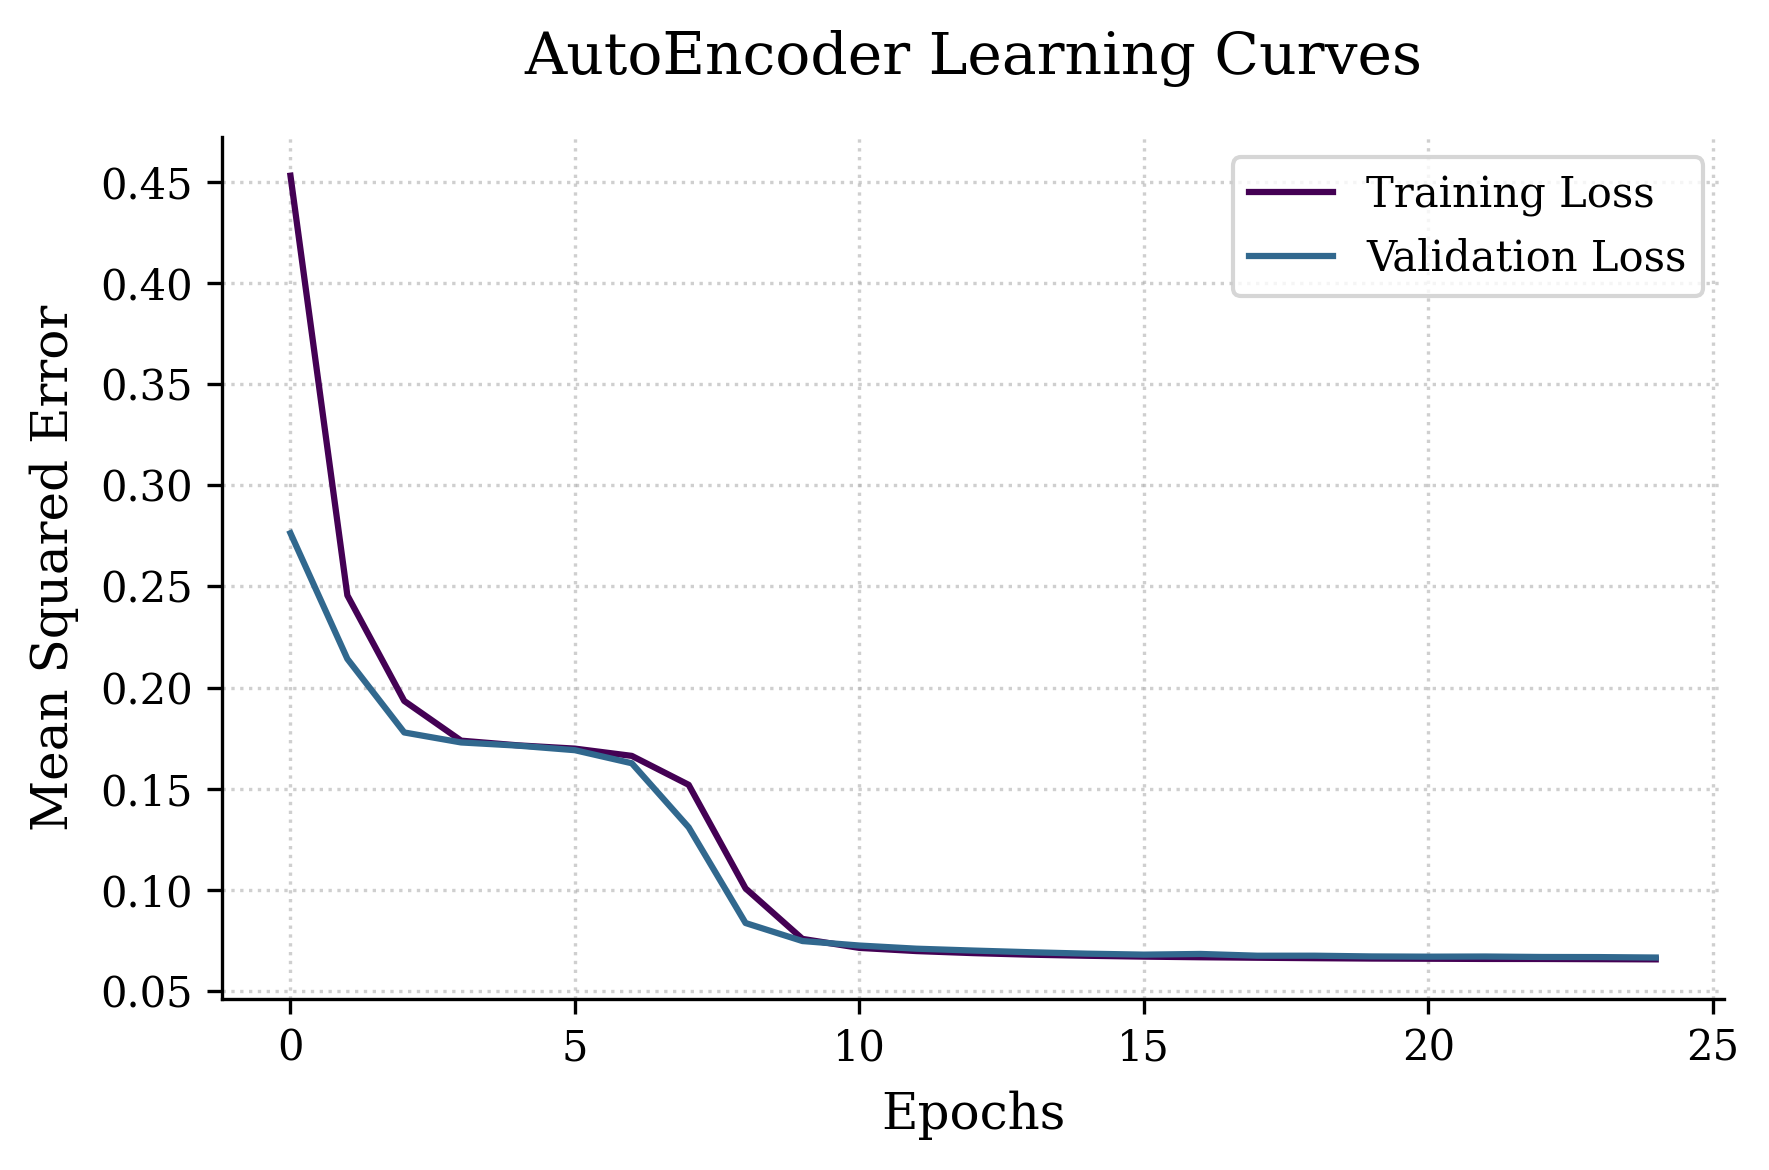

In [105]:
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')

plt.title('AutoEncoder Learning Curves', pad=15)
plt.xlabel('Epochs', labelpad=5)
plt.ylabel('Mean Squared Error', labelpad=5)
plt.legend(frameon=True, loc='upper right')

plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('autoencoder_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

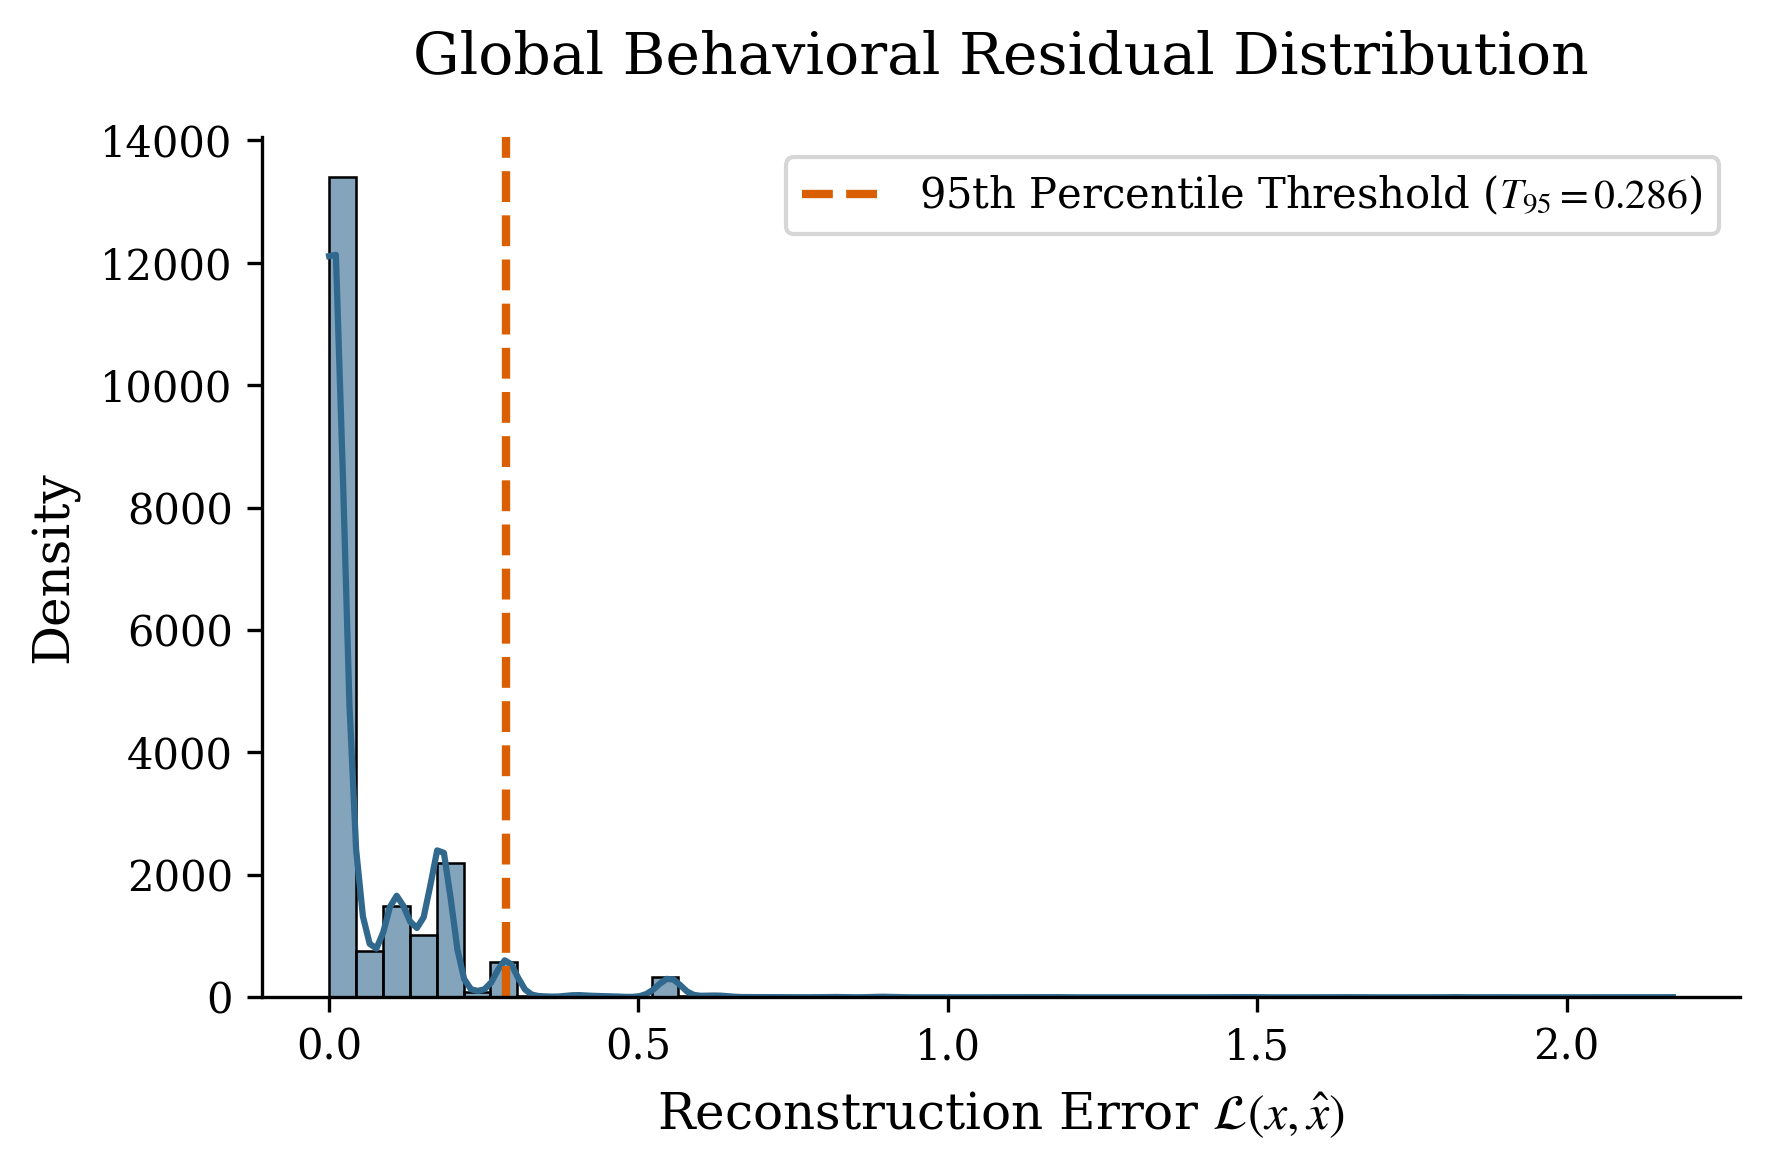

In [106]:
final_errors = val_recon_errors[-len(X_global_val_scaled):]
threshold = np.percentile(final_errors, 95)

plt.figure(figsize=(6, 4))
sns.histplot(final_errors, bins=50, kde=True, color='#31688e', alpha=0.6)
plt.axvline(threshold, color='#d95f02', linestyle='--', linewidth=2,
            label=f'95th Percentile Threshold ($T_{{95}} = {threshold:.3f}$)')
plt.title('Global Behavioral Residual Distribution', pad=15)
plt.xlabel(r'Reconstruction Error $\mathcal{L}(x, \hat{x})$', labelpad=5)
plt.ylabel('Density', labelpad=5)
plt.legend(loc='upper right', frameon=True)
sns.despine()

plt.tight_layout()
plt.savefig('dist_recon_errors.png', dpi=300, bbox_inches='tight')
plt.show()

### Isolation Forest

In [36]:
isoforest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    max_samples='auto',
    random_state=32
)

In [37]:
isoforest.fit(X_user_train_scaled)

IsolationForest(contamination=0.01, random_state=32)

In [38]:
val_scores = isoforest.decision_function(X_user_val_scaled)
val_preds = isoforest.predict(X_user_val_scaled)  # -1 = anomaly, 1 = normal

print(f"Fraction of anomalies detected in val: {(val_preds == -1).mean():.4f}")

Fraction of anomalies detected in val: 0.0100


In [39]:
with open('isoforest.pkl', 'wb') as isf:
  pickle.dump(isoforest, isf)

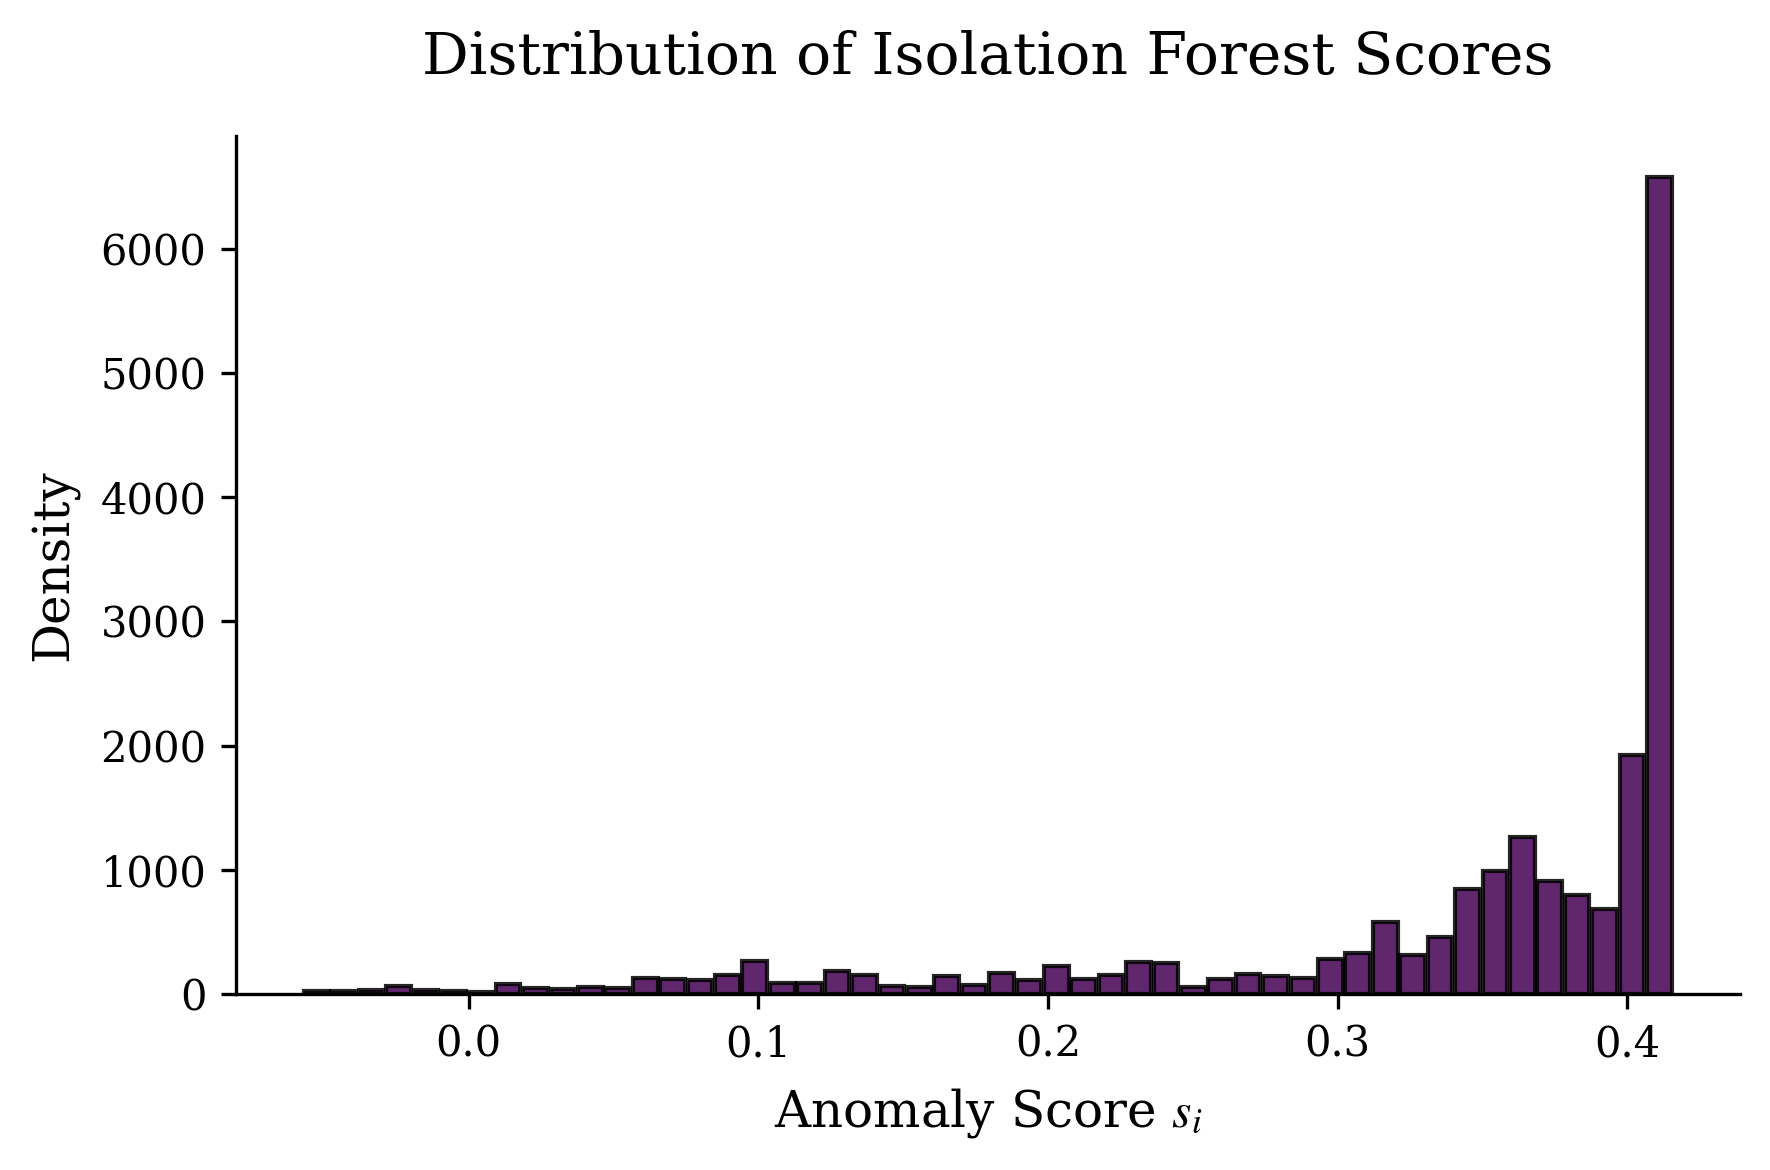

In [112]:
plt.figure(figsize=(6, 4))
plt.hist(val_scores, bins=50, alpha=0.85, rwidth=0.9)

plt.title('Distribution of Isolation Forest Scores', pad=15)

plt.xlabel(r'Anomaly Score $s_i$', labelpad=5)
plt.ylabel('Density', labelpad=5)

# threshold = np.percentile(val_scores, 95)
# plt.axvline(threshold, color='#d95f02', linestyle='--', linewidth=1.5,
#            label=f'Threshold ($T_{{95}} = {threshold:.2f}$)')
# plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('isoforest_score_dist.png', dpi=300, bbox_inches='tight')
plt.show()

### Anomaly Score Fusion

In [55]:
final_val_recon_errors = val_recon_errors[-len(X_global_val_scaled):]
min_recon = np.min(final_val_recon_errors)
max_recon = np.max(final_val_recon_errors)
scaled_recon_errors = (final_val_recon_errors - min_recon) / (max_recon - min_recon)

In [58]:
min_si = np.min(val_scores)
max_si = np.max(val_scores)
scaled_si = (max_si - val_scores) / (max_si - min_si)
# flipping the direction, higher is anomalous and lower is normal to match autoencoder

In [60]:
alpha = 0.5
anomaly_scores = alpha * scaled_si + (1 - alpha) * scaled_recon_errors

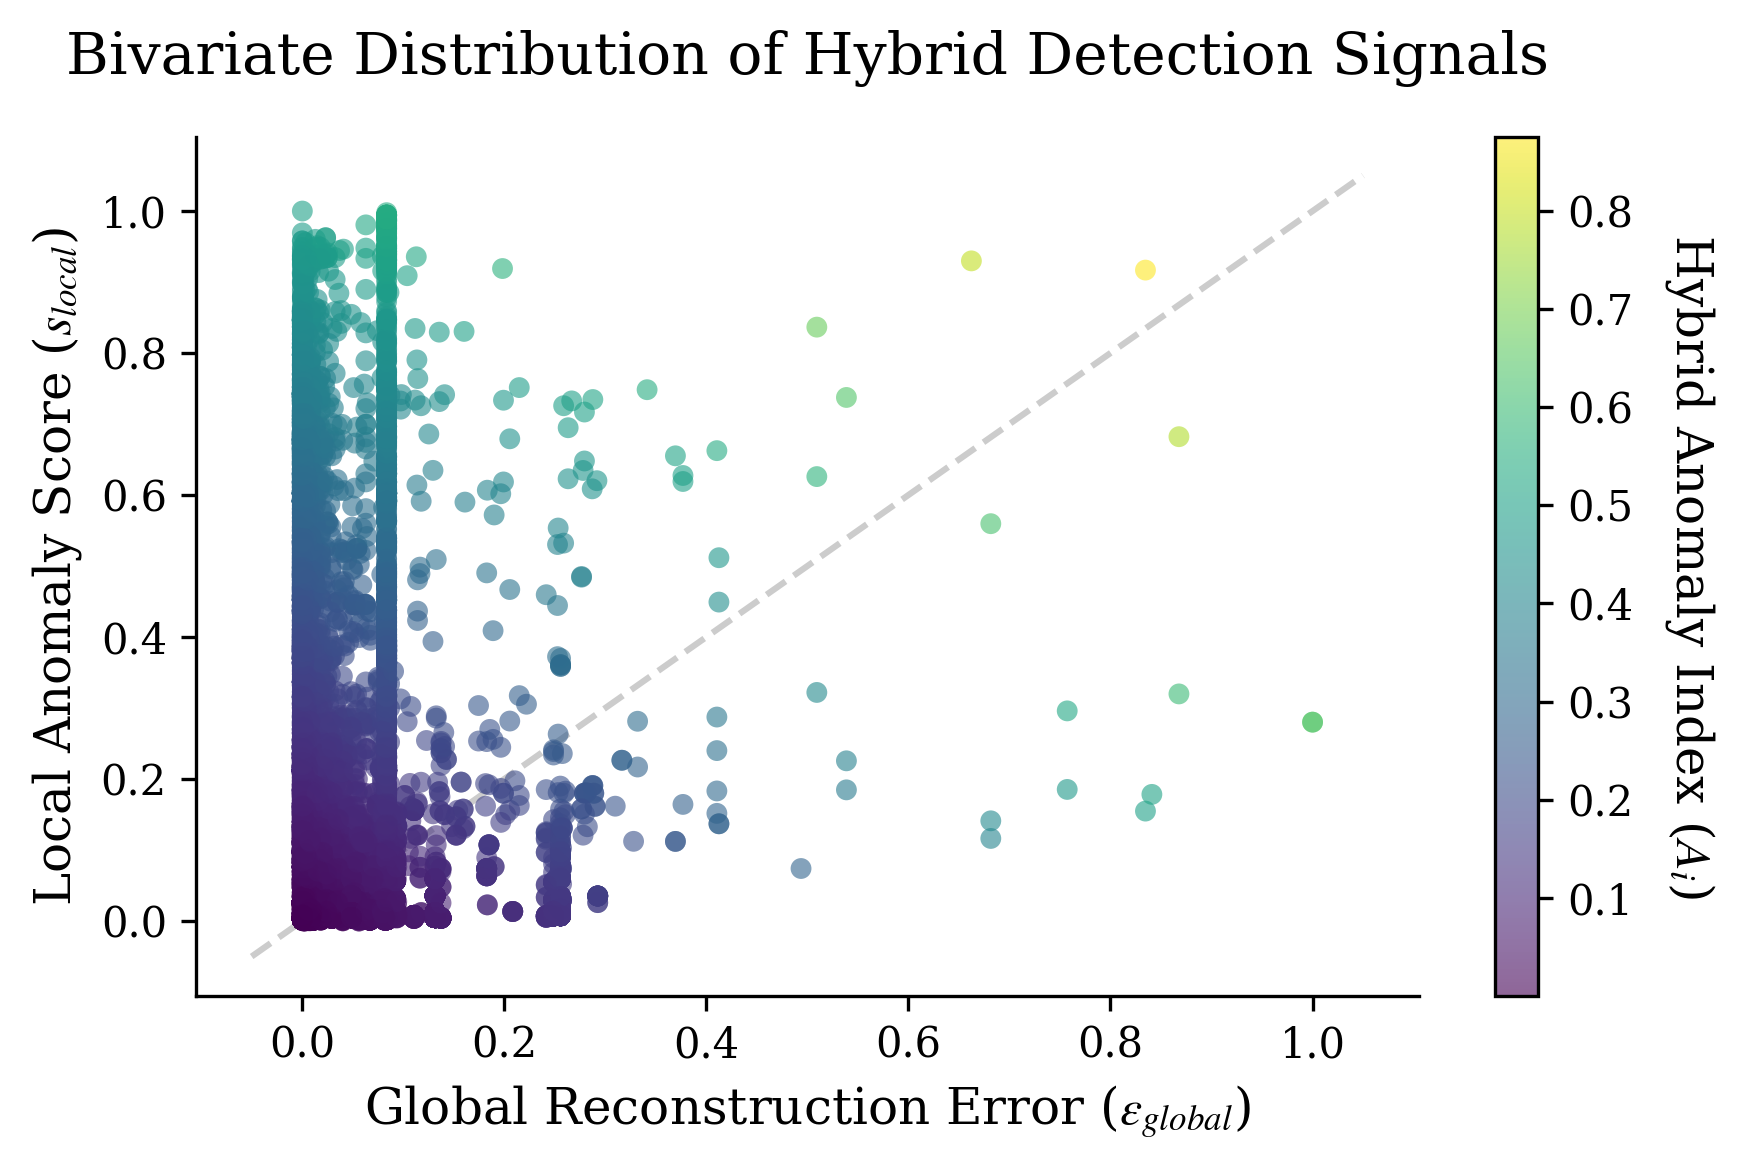

In [115]:
plt.figure(figsize=(6,4))
scatter = plt.scatter(scaled_recon_errors, scaled_si,
                      c=anomaly_scores, cmap='viridis',
                      alpha=0.6, s=25, edgecolor='none')

cbar = plt.colorbar(scatter)
cbar.set_label(r'Hybrid Anomaly Index ($A_{i}$)', rotation=270, labelpad=20)

plt.xlabel(r'Global Reconstruction Error ($\epsilon_{global}$)')
plt.ylabel(r'Local Anomaly Score ($s_{local}$)')
plt.title('Bivariate Distribution of Hybrid Detection Signals', pad=15)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

lims = [
    np.min([plt.xlim(), plt.ylim()]),
    np.max([plt.xlim(), plt.ylim()]),
]
plt.plot(lims, lims, 'k--', alpha=0.2, zorder=0, label='Unity Line')

plt.tight_layout()
plt.savefig('hybrid_score_fusion.png', dpi=300, bbox_inches='tight')
plt.show()

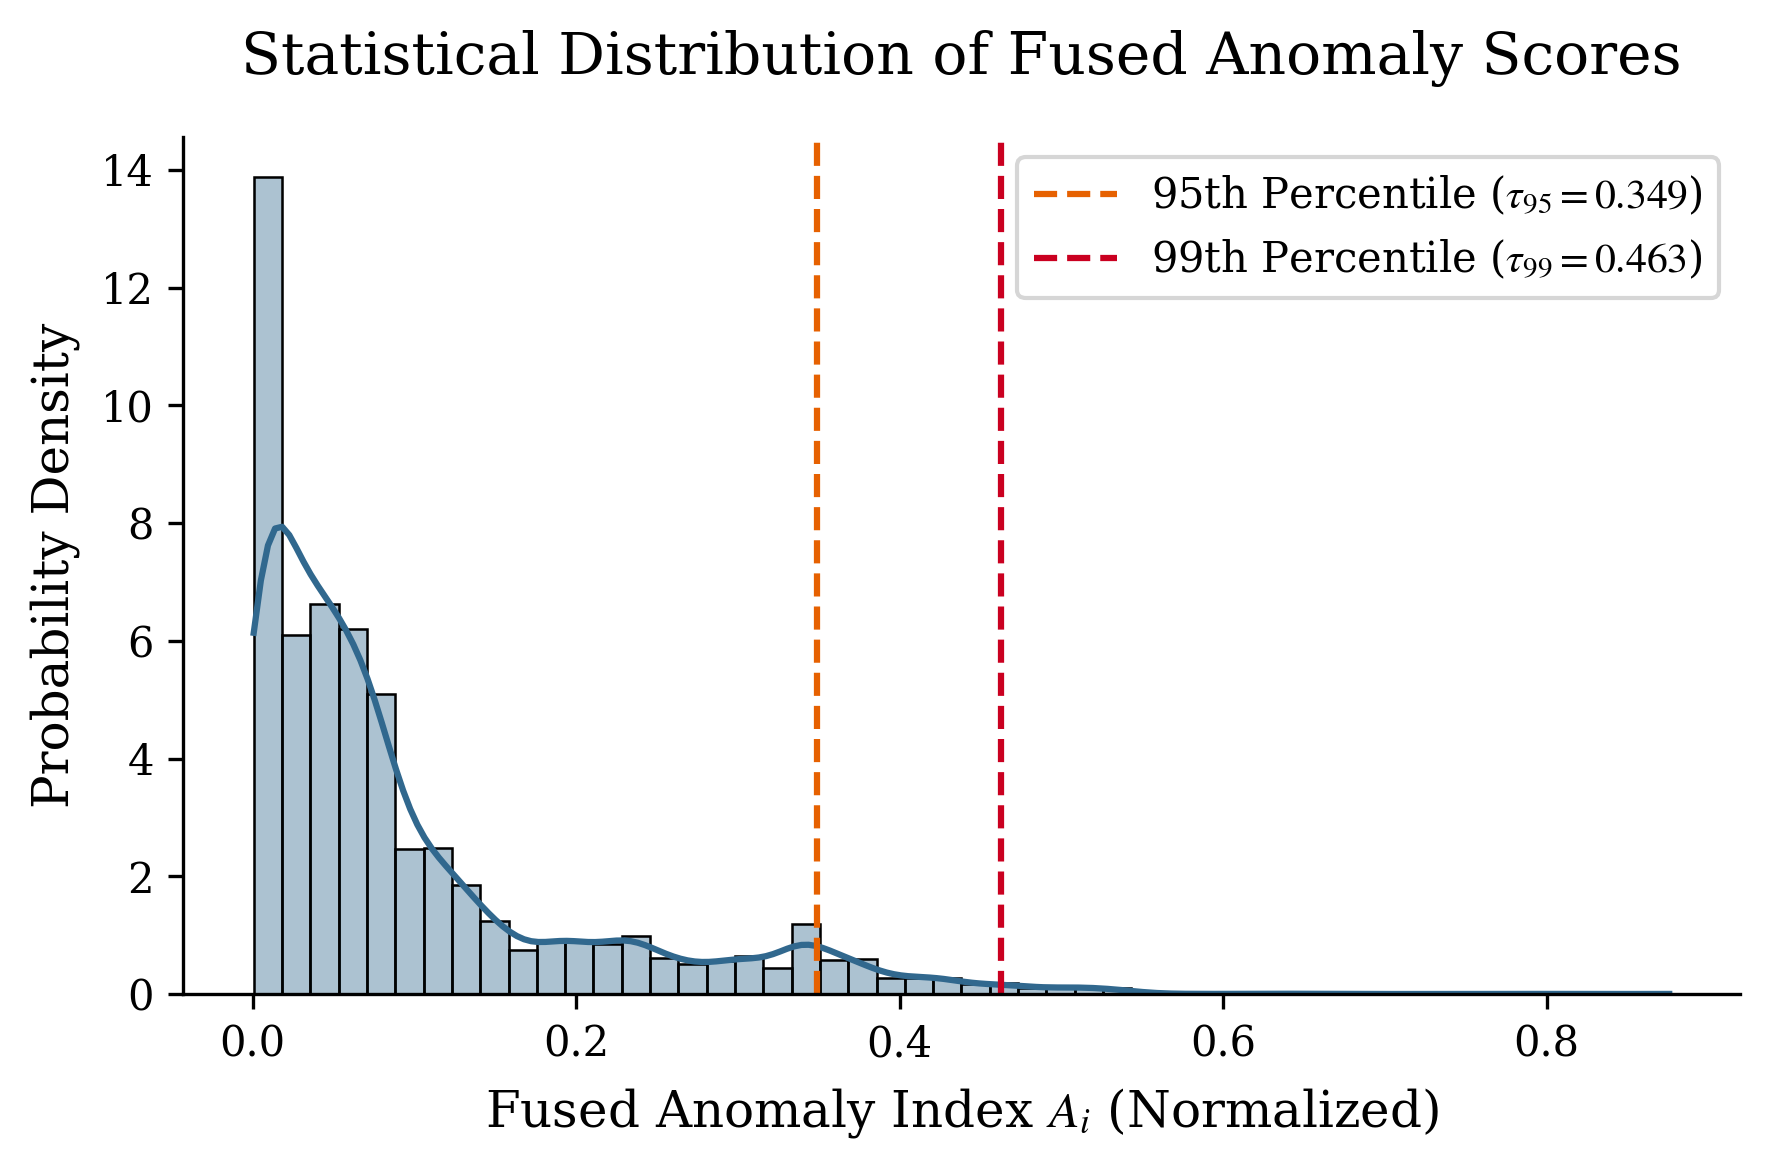

In [118]:
plt.figure(figsize=(6, 4))

thresh_95 = np.percentile(anomaly_scores, 95)
thresh_99 = np.percentile(anomaly_scores, 99)

sns.histplot(anomaly_scores, bins=50, kde=True, color='#31688e', stat="density", alpha=0.4)

plt.axvline(thresh_95, color='#e66101', linestyle='--', linewidth=1.5,
            label=f'95th Percentile ($\\tau_{{95}} = {thresh_95:.3f}$)')
plt.axvline(thresh_99, color='#ca0020', linestyle='--', linewidth=1.5,
            label=f'99th Percentile ($\\tau_{{99}} = {thresh_99:.3f}$)')

plt.title('Statistical Distribution of Fused Anomaly Scores', pad=15)
plt.xlabel(r'Fused Anomaly Index $A_i$ (Normalized)', labelpad=5)
plt.ylabel('Probability Density', labelpad=5)

plt.legend(frameon=True, loc='upper right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('hybrid_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

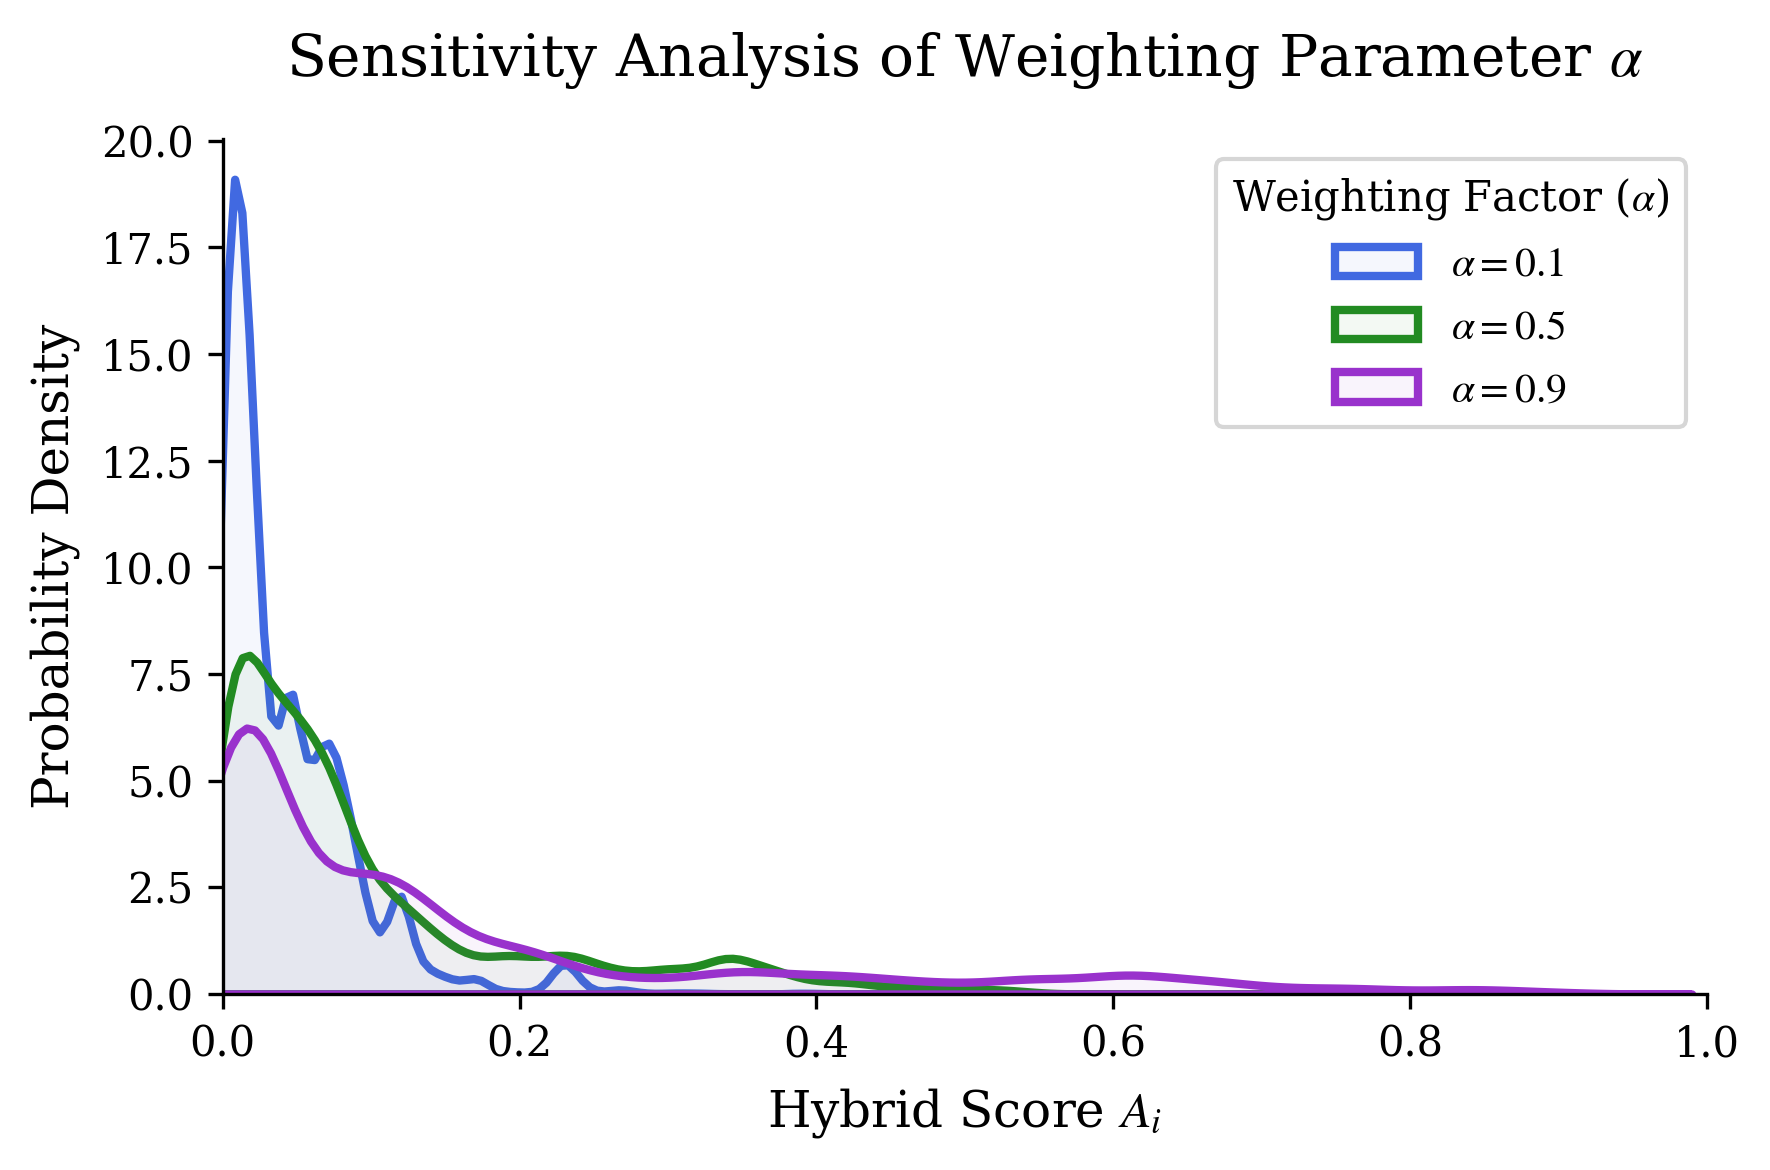

In [123]:
plt.figure(figsize=(6, 4))

alphas = [0.1, 0.5, 0.9]
colors = ['royalblue', 'forestgreen', 'darkorchid']

for a, color in zip(alphas, colors):
    temp_scores = a * scaled_si + (1 - a) * scaled_recon_errors

    sns.kdeplot(temp_scores,
                label=rf'$\alpha = {a}$',
                color=color,
                linewidth=2,
                fill=True,
                alpha=0.05)

plt.title('Sensitivity Analysis of Weighting Parameter ' + r'$\alpha$', pad=15)
plt.xlabel(r'Hybrid Score $A_i$', labelpad=5)
plt.ylabel('Probability Density', labelpad=5)
plt.xlim(0, 1)

plt.legend(title=r'Weighting Factor ($\alpha$)', frameon=True, loc='upper right')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('alpha_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()